In [40]:
import numpy as np

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
])

y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

print("Study Hours:")
print(X.flatten())

print("Results:")
print(y)

Study Hours:
[ 1  2  3  4  5  6  7  8  9 10]
Results:
[0 0 0 0 0 1 1 1 1 1]


In [41]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

model.fit(X,y)

print("Decision Tree trained Successfully")

Decision Tree trained Successfully


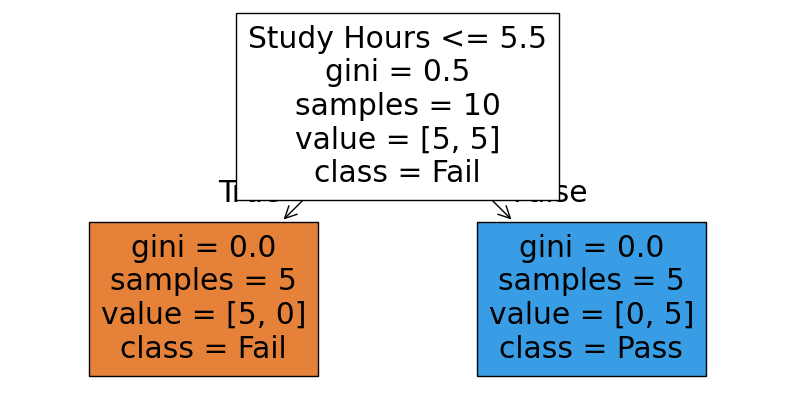

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_tree(
    model,
    feature_names=["Study Hours"],
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

In [43]:
new_students = np.array([
    [3],
    [5],
    [6],
    [8]
])

predictions = model.predict(new_students)

for hours, prediction in zip(new_students.flatten(),predictions):
    result = "Pass" if prediction == 1 else "Fail"
    print(f"Study Hours {hours} -> prediction: {result}")


Study Hours 3 -> prediction: Fail
Study Hours 5 -> prediction: Fail
Study Hours 6 -> prediction: Pass
Study Hours 8 -> prediction: Pass


In [44]:
from sklearn.tree import DecisionTreeClassifier

shallow_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

deep_tree = DecisionTreeClassifier(
    random_state=42
)

shallow_tree.fit(X,y)
deep_tree.fit(X,y)

print("Shallow Tree Training Accuracy: ",shallow_tree.score(X,y))
print("Deep Tree Training Accuracy: ",deep_tree.score(X,y))

Shallow Tree Training Accuracy:  1.0
Deep Tree Training Accuracy:  1.0


In [45]:
print("Shallow Tree Depth: ",shallow_tree.get_depth())
print("Deep Tree Depth: ",deep_tree.get_depth())

print("Shallow Tree Leaves: ",shallow_tree.get_n_leaves())
print("Deep Tree Leaves: ",deep_tree.get_n_leaves())

Shallow Tree Depth:  1
Deep Tree Depth:  1
Shallow Tree Leaves:  2
Deep Tree Leaves:  2


In [46]:
x_complex = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10]
])

y_complex = np.array([
    0, 0, 1,  0, 1,
    1, 0, 1, 1, 0
])

print("Study Hours: ",x_complex.flatten())
print("Results: ",y_complex)

Study Hours:  [ 1  2  3  4  5  6  7  8  9 10]
Results:  [0 0 1 0 1 1 0 1 1 0]


In [47]:
shallow_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

deep_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

shallow_tree.fit(x_complex,y_complex)
deep_tree.fit(x_complex,y_complex)

print("Shallow Tree Training Accuracy: ",shallow_tree.score(x_complex,y_complex))
print("Deep Tree Training Accuracy: ",deep_tree.score(x_complex,y_complex))

print("Shallow Tree Depth: ",shallow_tree.get_depth())
print("Deep Tree Depth: ",deep_tree.get_depth())

Shallow Tree Training Accuracy:  0.7
Deep Tree Training Accuracy:  1.0
Shallow Tree Depth:  1
Deep Tree Depth:  6


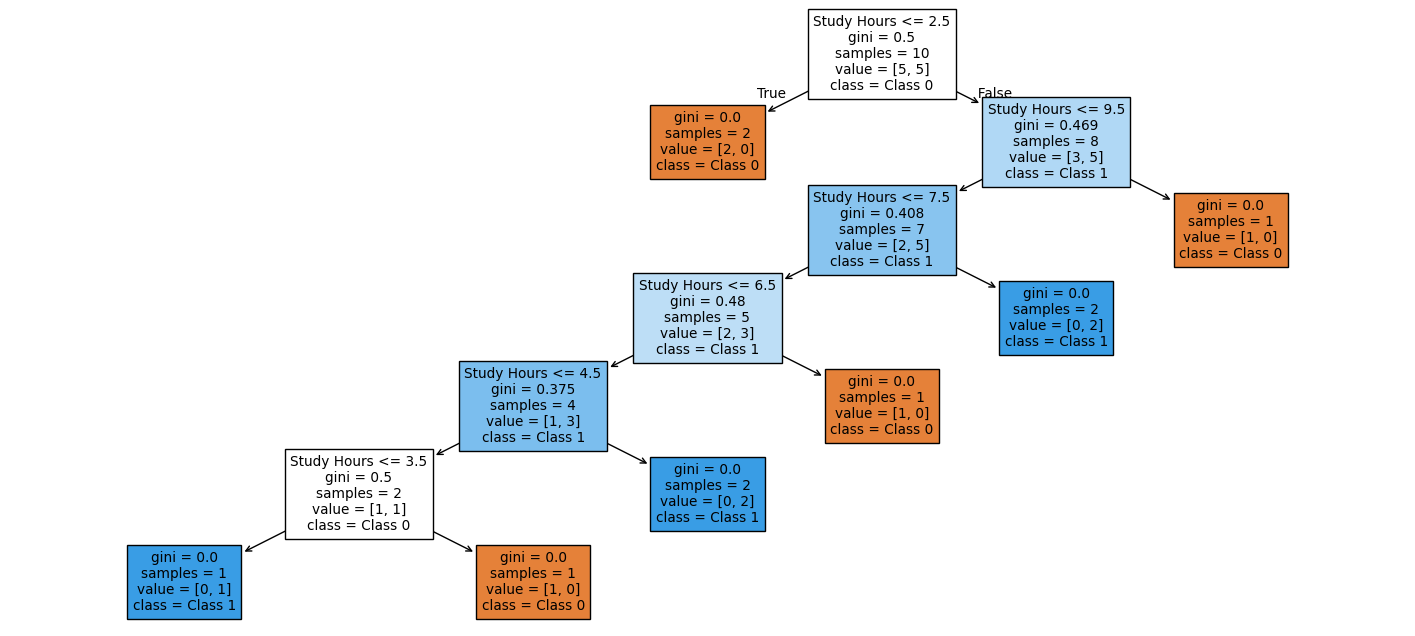

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

plot_tree(
    deep_tree,
    feature_names=["Study Hours"],
    class_names=["Class 0","Class 1"],
    filled=True
)

plt.show()

In [49]:
for depth in [1, 2, 3, 4, 5, None]:
  tree = DecisionTreeClassifier(
      max_depth=depth,
      random_state=42
  )

tree.fit(x_complex,y_complex)

print("Max Depth: ",depth,
      "| Actual Depth: ",tree.get_depth(),
      "| Training Accuracy: ",tree.score(x_complex,y_complex)
    )

Max Depth:  None | Actual Depth:  6 | Training Accuracy:  1.0


In [50]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x_complex,
    y_complex,
    test_size=0.3,
    random_state=42,
    stratify=y_complex
)

for depth in [1, 2, 3, 4, 5, None]:
  tree = DecisionTreeClassifier(
      max_depth=depth,
      random_state=42
  )

  tree.fit(X_train,y_train)

  print("Depth: ",depth,
        "Training Accuracy: ",tree.score(X_train,y_train),
        "Testing Accuracy: ",tree.score(X_test,y_test)
  )

Depth:  1 Training Accuracy:  0.7142857142857143 Testing Accuracy:  0.6666666666666666
Depth:  2 Training Accuracy:  0.8571428571428571 Testing Accuracy:  0.6666666666666666
Depth:  3 Training Accuracy:  0.8571428571428571 Testing Accuracy:  0.6666666666666666
Depth:  4 Training Accuracy:  1.0 Testing Accuracy:  0.6666666666666666
Depth:  5 Training Accuracy:  1.0 Testing Accuracy:  0.6666666666666666
Depth:  None Training Accuracy:  1.0 Testing Accuracy:  0.6666666666666666


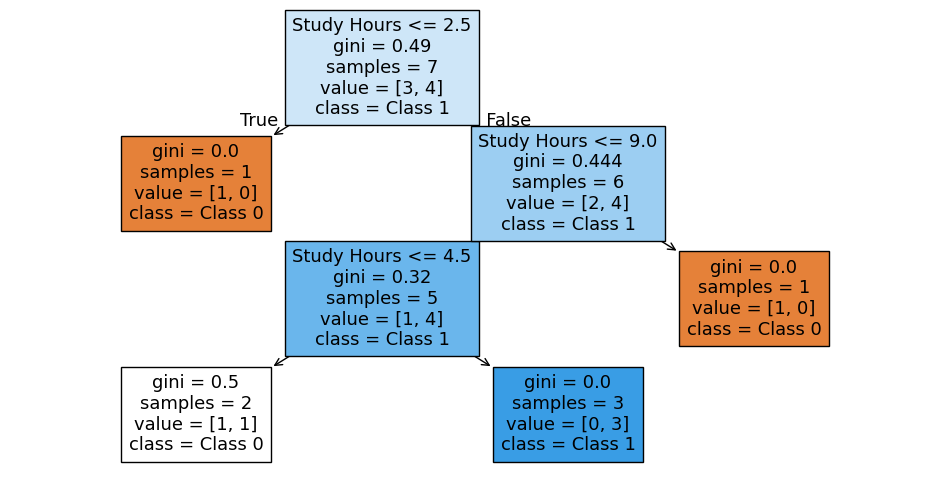

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = DecisionTreeClassifier(max_depth=3,random_state=42)
tree.fit(X_train,y_train)

plt.figure(figsize=(12,6))

plot_tree(
    tree,
    feature_names=["Study Hours"],
    class_names=["Class 0", "Class 1"],
    filled=True
)

plt.show()